In [1]:
import pandas as pd
import numpy as np


In [2]:
df_matches = pd.read_csv('../../data/preprocessed/imputed_data.csv')
df_matches.sort_values(by=["season", "stage", "date"], inplace=True)
season_labels, _ = pd.factorize(df_matches['result_match'])
feature_cols = [col for col in df_matches.columns if col not in
                ["result_match", "stage", "season", "date", "home_team", "away_team"]]

y = df_matches['result_match']
X = df_matches[feature_cols]

,match_api_id,points_home,points_away,home_team_last_goal,home_team_last_shoton,home_team_last_possession,away_team_last_goal,away_team_last_shoton,away_team_last_possession,avg_team_strength_home,...,rolling_stability_shoton_away,shot_efficiency_ratio_home,shot_efficiency_ratio_away,rolling_avg_goals_diff,rolling_stability_goal_diff,rolling_avg_goals_conversion_rate_diff,rolling_stability_goals_conversion_rate_diff,rolling_avg_shoton_diff,rolling_stability_shoton_diff,points_diff
0,489063,3.0,4.0,1.00,12.0,34.0,1.000000,1.0,55.0,78.318182,...,1.696473,708.002393,38243.046518,0.000000,-0.123974,-0.916667,-0.354619,11.000000,-0.484489,-1.0
1,489068,3.0,3.0,1.00,7.0,47.0,3.000000,1.0,47.0,63.924242,...,1.722986,708.016770,55893.419886,-2.000000,-0.440513,-2.857143,-0.532501,6.000000,-0.698056,0.0
2,489069,3.0,0.0,3.00,5.0,53.0,1.000000,2.0,66.0,71.318182,...,1.840763,0.870076,0.587148,2.000000,0.269952,0.100000,-0.031198,3.000000,-0.184114,3.0
3,489070,4.0,0.0,1.00,5.0,47.0,1.000000,7.0,52.0,63.318182,...,1.922500,0.713973,0.561366,0.000000,-0.074833,0.057143,-0.027866,-2.000000,-0.433978,4.0
4,489066,3.0,6.0,2.00,5.0,48.0,2.000000,11.0,46.0,77.030303,...,2.127722,708.016159,0.621578,0.000000,0.110656,0.218182,0.019558,-6.000000,-0.354946,-3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970,1987599,44.0,34.0,1.00,4.0,44.0,4.000000,6.0,69.0,72.327273,...,2.501802,0.221394,0.413129,-1.877456,-0.375831,0.071750,0.604273,-1.750375,0.469080,10.0
2971,1987598,49.0,80.0,2.00,5.0,53.0,3.000000,4.0,67.0,65.445455,...,2.081047,0.563487,0.584040,0.098747,-0.282355,-0.014761,-0.194222,-0.402411,-0.425180,-31.0
2972,1987597,68.0,17.0,2.00,7.0,31.0,1.666667,1.0,65.0,70.627273,...,3.830061,0.228152,0.117402,0.296724,0.415464,-0.535126,-0.536706,3.822830,-0.038204,51.0
2973,1987601,34.0,70.0,1.75,6.0,50.0,1.000000,6.0,47.0,79.690909,...,2.072934,0.249170,0.530648,-0.123565,-0.424164,0.329249,0.205247,-2.467804,0.639423,-36.0


In [5]:
X.columns

Index(['match_api_id', 'points_home', 'points_away', 'home_team_last_goal',
       'home_team_last_shoton', 'home_team_last_possession',
       'away_team_last_goal', 'away_team_last_shoton',
       'away_team_last_possession', 'avg_team_strength_home',
       'avg_team_strength_away', 'strength_difference',
       'avg_team_aggression_home', 'avg_team_aggression_away',
       'aggression_difference', 'avg_team_acceleration_home',
       'avg_team_acceleration_away', 'acceleration_difference',
       'goal_conversion_rate_home', 'goal_conversion_rate_away',
       'home_team_strength_x_acceleration',
       'away_team_strength_x_acceleration', 'rolling_avg_goals_home',
       'rolling_stability_goal_home', 'rolling_avg_goals_conversion_rate_home',
       'rolling_stability_goals_conversion_rate_home',
       'rolling_avg_shoton_home', 'rolling_stability_shoton_home',
       'rolling_avg_goals_away', 'rolling_stability_goal_away',
       'rolling_avg_goals_conversion_rate_away',
       

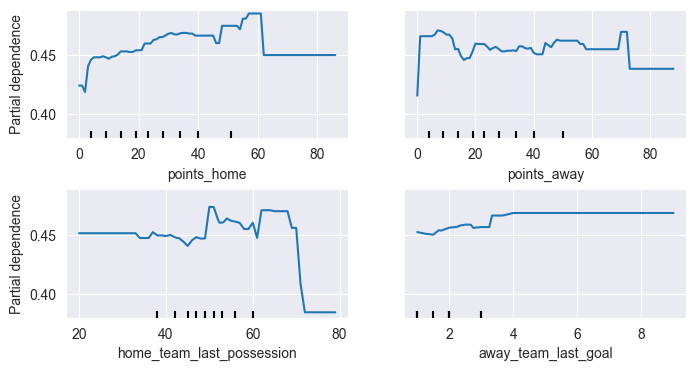

In [17]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

xgb = XGBClassifier(booster='gbtree',
                    objective='reg:logistic',
                    n_estimators=300,
                    max_depth=4,
                    min_child_weight=3)

model_pipeline = Pipeline(
    [('xgboost', xgb)])

model_pipeline.fit(X=X, y=y)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 4))  #B
fig.subplots_adjust(hspace=0.4, wspace=0.2)

PartialDependenceDisplay.from_estimator(model_pipeline,
                                        X=X,
                                        kind='average',
                                        features=['points_home', 'points_away', 'home_team_last_possession',
       'away_team_last_goal',
                                                  ],
                                        ax=axes)

for ax in axes.flatten():
    ax.axhline(y=0.5, color='red', linestyle='--')  #E

plt.show()

In [ ]:
[
    'points_diff',
    'rolling_avg_goals_diff',
    'rolling_avg_goals_conversion_rate_diff',
    'rolling_avg_shoton_away',
    'rolling_stability_shoton_home',
    'rolling_stability_goal_diff',
    'rolling_avg_goals_conversion_rate_home',
    'rolling_stability_goals_conversion_rate_home',
    'avg_team_acceleration_home',
    'rolling_avg_shoton_home',
    'goal_conversion_rate_away',
    'rolling_avg_goals_home',
    'acceleration_difference',
    'avg_team_aggression_home',
    'avg_team_aggression_away',
    'away_team_last_shoton',
    'home_team_last_possession',
    'away_team_last_possession',
    'aggression_difference',
]